In [26]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt  # optional
import seaborn as sns  # optional

import scanpy as sc
from scipy import sparse

import networkx as nx
import torch

In [27]:
import came
from came import pipeline, pp, pl

ROOT = Path(".")  # set root

In [4]:
ROOT

PosixPath('.')

In [5]:
import anndata as ad
import pandas as pd
from scipy.io import mmread

In [6]:
adata = sc.read_h5ad("/public/workspace/lhpeng/gwork/CAME/came/sample_data/raw-Baron_human.h5ad")

In [8]:
adata.obs

,cell_ontology_class,cell_ontology_id,cell_type1,dataset_name,donor,library,organ,organism,platform
index,,,,,,,,,
human3_lib4.final_cell_0810,type B pancreatic cell,CL:0000169,beta,Baron_human,human3,lib4,Pancreas,Homo sapiens,inDrop
human1_lib2.final_cell_0321,pancreatic ductal cell,CL:0002079,ductal,Baron_human,human1,lib2,Pancreas,Homo sapiens,inDrop
human2_lib1.final_cell_0107,type B pancreatic cell,CL:0000169,beta,Baron_human,human2,lib1,Pancreas,Homo sapiens,inDrop
human2_lib3.final_cell_0340,pancreatic A cell,CL:0000171,alpha,Baron_human,human2,lib3,Pancreas,Homo sapiens,inDrop
human1_lib3.final_cell_0389,type B pancreatic cell,CL:0000169,beta,Baron_human,human1,lib3,Pancreas,Homo sapiens,inDrop
...,...,...,...,...,...,...,...,...,...
human3_lib3.final_cell_0482,pancreatic A cell,CL:0000171,alpha,Baron_human,human3,lib3,Pancreas,Homo sapiens,inDrop
human4_lib3.final_cell_0416,pancreatic ductal cell,CL:0002079,ductal,Baron_human,human4,lib3,Pancreas,Homo sapiens,inDrop
human2_lib1.final_cell_0119,type B pancreatic cell,CL:0000169,beta,Baron_human,human2,lib1,Pancreas,Homo sapiens,inDrop


# data

In [3]:
import anndata as ad
import pandas as pd
from scipy.io import mmread

datadir=r"/public/workspace/lhpeng/data/GSE186158/Human/filtered_feature_bc_matrix/"

# 读取数据
matrix = mmread(datadir+"matrix.mtx.gz").tocsr()
barcodes = pd.read_csv(datadir+"barcodes.tsv.gz", header=None, sep="\t").values.flatten()
features = pd.read_csv(datadir+"features.tsv.gz", header=None, sep="\t", names=["gene_id", "gene_name"])

# 创建 AnnData 对象
adata = ad.AnnData(
    X=matrix,
    obs=pd.DataFrame(index=barcodes),
    var=features.set_index("gene_id")
)

# 保存为 h5ad 格式
adata.write("human.h5ad")

ValueError: Observations annot. `obs` must have number of rows of `X` (33538), but has 16953 rows.

In [4]:
print("矩阵 X 的行数:", matrix.shape[0])
print("barcodes 的数量:", len(barcodes))

矩阵 X 的行数: 33538
barcodes 的数量: 16953


In [5]:
import anndata as ad
import pandas as pd
from scipy.io import mmread

datadir=r"/public/workspace/lhpeng/data/GSE186158/Human/filtered_feature_bc_matrix/"

# 读取数据
matrix = mmread(datadir+"matrix.mtx.gz").tocsr()
matrix = matrix.T # 矩阵转置
barcodes = pd.read_csv(datadir+"barcodes.tsv.gz", header=None, sep="\t").values.flatten()
features = pd.read_csv(datadir+"features.tsv.gz", header=None, sep="\t", names=["gene_id", "gene_name"])

# 创建 AnnData 对象
adata = ad.AnnData(
    X=matrix,
    obs=pd.DataFrame(index=barcodes),
    var=features.set_index("gene_id")
)

# 保存为 h5ad 格式
# adata.write("human.h5ad")

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
# 检查重复的gene_id
duplicate_genes = features[features.duplicated('gene_id')]['gene_id'].unique()
print(f"发现{len(duplicate_genes)}个重复的gene_id:")
print(duplicate_genes)

发现24个重复的gene_id:
['RGS5' 'TBCE' 'PDE11A' 'LINC01238' 'PRSS50' 'CYB561D2' 'ATXN7' 'TXNRD3NB'
 'CCDC39' 'MATR3' 'SOD2' 'POLR2J3' 'ABCF2' 'TMSB15B' 'PINX1' 'LINC01505'
 'IGF2' 'HSPA14' 'EMG1' 'DIABLO' 'LINC02203' 'COG8' 'SCO2' 'H2BFS']


In [7]:
# 查看重复的gene_id及其对应的gene_name
duplicate_df = features[features.duplicated('gene_id', keep=False)]  # 保留所有重复行
duplicate_df = duplicate_df.sort_values('gene_id')  # 按gene_id排序
print(duplicate_df)

                   gene_id        gene_name
ENSG00000033050      ABCF2  Gene Expression
ENSG00000285292      ABCF2  Gene Expression
ENSG00000285258      ATXN7  Gene Expression
ENSG00000163635      ATXN7  Gene Expression
ENSG00000145075     CCDC39  Gene Expression
ENSG00000284862     CCDC39  Gene Expression
ENSG00000272617       COG8  Gene Expression
ENSG00000213380       COG8  Gene Expression
ENSG00000114395   CYB561D2  Gene Expression
ENSG00000271858   CYB561D2  Gene Expression
ENSG00000184047     DIABLO  Gene Expression
ENSG00000284934     DIABLO  Gene Expression
ENSG00000268439       EMG1  Gene Expression
ENSG00000126749       EMG1  Gene Expression
ENSG00000274559      H2BFS  Gene Expression
ENSG00000234289      H2BFS  Gene Expression
ENSG00000187522     HSPA14  Gene Expression
ENSG00000284024     HSPA14  Gene Expression
ENSG00000167244       IGF2  Gene Expression
ENSG00000284779       IGF2  Gene Expression
ENSG00000261186  LINC01238  Gene Expression
ENSG00000237940  LINC01238  Gene

In [10]:
# 为重复的 ID 添加后缀（如_1、_2）
adata.var_names_make_unique()

# 保存为 h5ad 格式
adata.write("human.h5ad")

In [1]:
import os
# 获取当前工作路径（即当前代码运行时所在的目录路径）
current_path = os.getcwd()  
print(current_path)

/public/workspace/lhpeng/gwork/CAME/SP


# load data

In [9]:
# ========= customized paths ==========

dsnames = ('Imm_human', 'Imm_mouse')  # the dataset names, set by user
dsn1, dsn2 = dsnames

path_rawdata1 = "/public/workspace/lhpeng/TACMAN/data/GSE186158/human_annot.h5ad"
path_rawdata2 = "/public/workspace/lhpeng/gwork/cell_annotation/mouse_annot.h5ad"

In [10]:
path_varmap = "/public/workspace/lhpeng/TACMAN/homo/human_to_mouse.txt"

#path_varmap_1v1 = CAME_ROOT / f'came/sample_data/gene_matches_1v1_human2mouse.csv'

In [11]:
# ========= load data =========
df_varmap = pd.read_csv(path_varmap)
df_varmap_1v1 = came.pp.take_1v1_matches(df_varmap)

adata_raw1 = sc.read_h5ad(path_rawdata1)
adata_raw2 = sc.read_h5ad(path_rawdata2)
adatas = [adata_raw1, adata_raw2]

In [12]:
adata_raw2.obs["cell_type"].value_counts()

cell_type
B cells            7014
T cells            5731
NK cells            467
Neutrophils         127
Dendritic Cells      48
Mast Cells           22
Name: count, dtype: int64

In [13]:
adatas

[AnnData object with n_obs × n_vars = 14118 × 17611
     obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'umi_gene_ratio', 'cell_type'
     var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts',
 AnnData object with n_obs × n_vars = 13409 × 15293
     obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'umi_gene_ratio', 'cell_type', 'sub_cell_type', 'sp'
     var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'n_cells']

In [14]:
key_class1 = 'cell_type'  
key_class2 = 'cell_type'  

In [16]:
time_tag = came.make_nowtime_tag()
resdir = ROOT /'_temp' / f'{dsnames}-{time_tag}'  # set by user
figdir = resdir / 'figs'
came.check_dirs(figdir)  # check and make the directory

a new directory made:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs


In [17]:
sc.pp.filter_genes(adata_raw1, min_cells=3)
sc.pp.filter_genes(adata_raw2, min_cells=3)

In [18]:
# Inspect classes
if key_class2 is not None:
    group_counts_ori = pd.concat([
        pd.value_counts(adata_raw1.obs[key_class1]),
        pd.value_counts(adata_raw2.obs[key_class2]),
    ], axis=1, keys=dsnames)
else:
    group_counts_ori = pd.value_counts(adata_raw1.obs[key_class1])

group_counts_ori

,Imm_human,Imm_mouse
cell_type,,
T cells,4947.0,5731.0
B cells,4582.0,7014.0
NK cells,3631.0,467.0
Plasma cells,750.0,NaN
Macrophages,208.0,NaN
Neutrophils,NaN,127.0
Dendritic Cells,NaN,48.0
Mast Cells,NaN,22.0


# 1 The default pipeline of CAME
Parameter settings.

In [19]:
# The numer of training epochs
# (a recommended setting is 200-400 for whole-graph training, and 80-200 for sub-graph training)
n_epochs = 300

# The training batch size
# When the GPU memory is limited, set 4096 or more if possible.
batch_size = None

# The number of epochs to skip for checkpoint backup
n_pass = 100

# Whether to use the single-cell networks
use_scnets = True

# The number of top DEGs to take as the node-features of each cells.
# You set it 70-100 for distant species pairs.
ntop_deg = 50

# The number of top DEGs to take as the graph nodes, which can be directly displayed on the UMAP plot.
ntop_deg_nodes = 50
# The source of the node genes; use both DEGs and HVGs by default
node_source = 'deg,hvg'

# Whether to take into account the non-1v1 variables as the node features.
keep_non1v1_feats = True

In [20]:
came_inputs, (adata1, adata2) = pipeline.preprocess_unaligned(
    adatas,
    key_class=key_class1,
    use_scnets=use_scnets,
    ntop_deg=ntop_deg,
    ntop_deg_nodes=ntop_deg_nodes,
    node_source=node_source,
)

outputs = pipeline.main_for_unaligned(
    **came_inputs,
    df_varmap=df_varmap,
    df_varmap_1v1=df_varmap_1v1,
    dataset_names=dsnames,
    key_class1=key_class1,
    key_class2=key_class2,
    do_normalize=True,
    keep_non1v1_feats=keep_non1v1_feats,
    n_epochs=n_epochs,
    resdir=resdir,
    n_pass=n_pass,
    batch_size=batch_size,
    plot_results=True,
)
dpair = outputs['dpair']
trainer = outputs['trainer']
h_dict = outputs['h_dict']
out_cell = outputs['out_cell']
predictor = outputs['predictor']


obs_ids1, obs_ids2 = dpair.obs_ids1, dpair.obs_ids2
obs = dpair.obs
classes = predictor.classes

[leiden] Time used:  19.5446 s
already exists:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs
already exists:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)
trans.shape= (405, 412)
[*] Setting dataset names:
	0-->Imm_human
	1-->Imm_mouse
[*] Setting aligned features for observation nodes (self._features)
[*] Setting un-aligned features (`self._ov_adjs`) for making links connecting observation and variable nodes
[*] Setting adjacent matrix connecting variables from these 2 datasets (`self._vv_adj`)
-------------------- Summary of the DGL-Heterograph --------------------
Graph(num_nodes={'cell': 27527, 'gene': 5720},
      num_edges={('cell', 'express', 'gene'): 8087899, ('cell', 'self_loop_cell', 'cell'): 27527, ('cell', 'similar_to', 'cell'): 183716, ('gene', 'expressed_by', 'cell'): 8087899, ('gene', 'homolog_with', 'gene'): 10836},
      metagraph=[('cell', 'gene', 'express'), ('cell', 'cell', 'self_loop_cell'), ('cell', 'cell', 'similar_to'), ('gene', 'cell', 'expressed

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/dgl/backend/pytorch/tensor.py:352: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), "Cannot convert view " \


Epoch 0000 | Train Acc: 0.0147 | Test: 0.0000 (max=0.0000) | AMI=0.0000 | Time: 1.7136
Epoch 0005 | Train Acc: 0.2572 | Test: 0.0348 (max=0.0348) | AMI=0.0000 | Time: 1.3513
Epoch 0010 | Train Acc: 0.4054 | Test: 0.4071 (max=0.4071) | AMI=0.0666 | Time: 1.3139
Epoch 0015 | Train Acc: 0.3504 | Test: 0.4274 (max=0.4274) | AMI=0.0000 | Time: 1.2989
Epoch 0020 | Train Acc: 0.4761 | Test: 0.4279 (max=0.4279) | AMI=0.0002 | Time: 1.2911
Epoch 0025 | Train Acc: 0.6489 | Test: 0.8657 (max=0.8657) | AMI=0.3919 | Time: 1.2784
Epoch 0030 | Train Acc: 0.6534 | Test: 0.9112 (max=0.9112) | AMI=0.4305 | Time: 1.2745
Epoch 0035 | Train Acc: 0.7702 | Test: 0.8918 (max=0.9112) | AMI=0.4457 | Time: 1.2692
Epoch 0040 | Train Acc: 0.8080 | Test: 0.8552 (max=0.9112) | AMI=0.4435 | Time: 1.2663
Epoch 0045 | Train Acc: 0.8350 | Test: 0.8701 (max=0.9112) | AMI=0.4529 | Time: 1.2659
Epoch 0050 | Train Acc: 0.8227 | Test: 0.8959 (max=0.9112) | AMI=0.4741 | Time: 1.2692
Epoch 0055 | Train Acc: 0.8681 | Test: 0.91

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/came/utils/_base_trainer.py:193: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sdct = torch.loa

object saved into:
	 _temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/datapair_init.pickle


In [21]:
outputs

{'dpair': <came.datapair.unaligned.DataPair at 0x7f316c9b05b0>,
 'trainer': <came.utils.train.Trainer at 0x7f316c9b4160>,
 'h_dict': {'cell': array([[-3.8516461e-03,  4.0840134e-01, -3.1073082e-02, ...,
           9.2098820e-01, -3.4821488e-02, -0.0000000e+00],
         [-6.9798445e-03, -6.5742955e-02, -9.9809645e-03, ...,
           3.1795877e-01, -5.3852394e-02,  1.1885273e+00],
         [-9.7914692e-03,  4.1902524e-01, -5.0122462e-02, ...,
           0.0000000e+00,  6.0305947e-01, -8.2576416e-02],
         ...,
         [-3.4723572e-02,  0.0000000e+00, -4.4676922e-02, ...,
           0.0000000e+00,  9.2096037e-01, -1.7942084e-02],
         [ 4.7185478e-01,  7.1837604e-01, -8.4873021e-02, ...,
          -2.9607926e-02,  0.0000000e+00, -6.8688713e-02],
         [ 0.0000000e+00, -4.1326554e-04, -3.6040861e-02, ...,
           2.3185635e+00,  0.0000000e+00, -3.9320104e-02]], dtype=float32),
  'gene': array([[-0.02615277,  0.5110059 ,  0.2046273 , ..., -0.0420417 ,
          -0.        ,

In [28]:
# 查询数据集的列联表
y_true = obs['celltype'][obs_ids2].values
y_pred = obs['predicted'][obs_ids2].values

ax, contmat = pl.plot_contingency_mat(
    y_true, y_pred, norm_axis=1,
    order_rows=False, order_cols=False,
)
pl._save_with_adjust(ax.figure, figdir / 'contingency_mat.png')
ax.figure

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

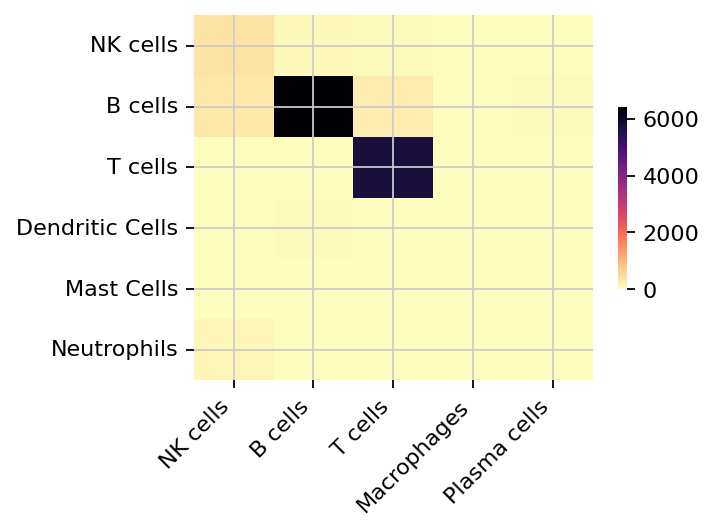

In [23]:
ax, contmat = pl.plot_contingency_mat(
    y_true, y_pred, norm_axis=None,  # 不进行归一化
    order_rows=False, order_cols=False,
)

In [128]:
# 先检查数据类型
print(f"y_true shape: {y_true.shape}, dtype: {y_true.dtype}")
print(f"y_pred shape: {y_pred.shape}, dtype: {y_pred.dtype}")

# 检查是否有空值
print(f"y_true unique: {np.unique(y_true)}")
print(f"y_pred unique: {np.unique(y_pred)}")

y_true shape: (13409,), dtype: object
y_pred shape: (13409,), dtype: object
y_true unique: ['B cells' 'Cytotoxic T cells' 'Macrophages' 'NK cells' 'Neutrophils'
 'T cells']
y_pred unique: ['B cells' 'ILC' 'Plasma cells' 'T cells']


figure has been saved into:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs/heatmap_probas.pdf


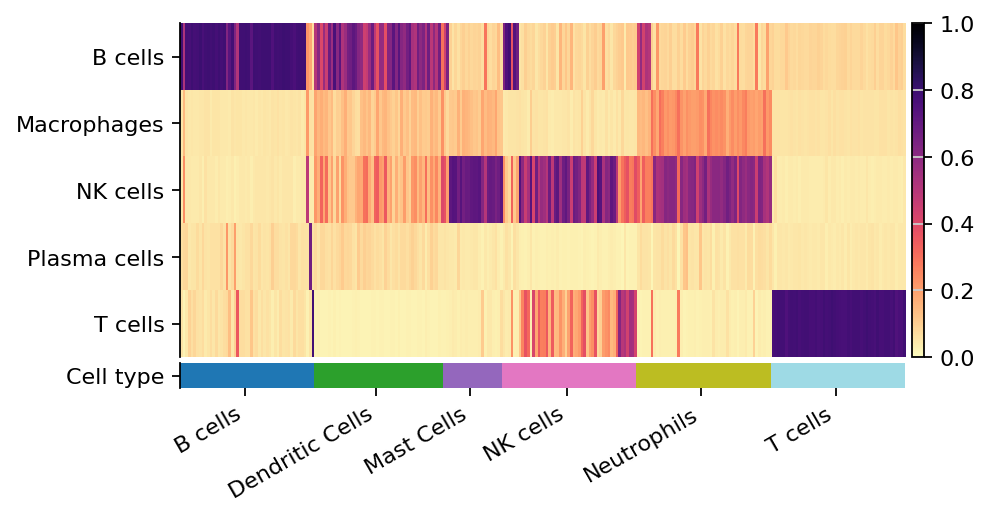

In [29]:
name_label = 'celltype'
cols_anno = ['celltype', 'predicted'][:]
df_probs = obs[list(classes)]


gs = pl.wrapper_heatmap_scores(
        df_probs.iloc[obs_ids2], obs.iloc[obs_ids2], ignore_index=True,
        col_label='celltype', col_pred='predicted',
        n_subsample=50,  # sampling 50 cells for each group
        cmap_heat='magma_r',
        fp=figdir / f'heatmap_probas.pdf'
    )

gs.figure

figure has been saved into:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs/heatmap_probas.png


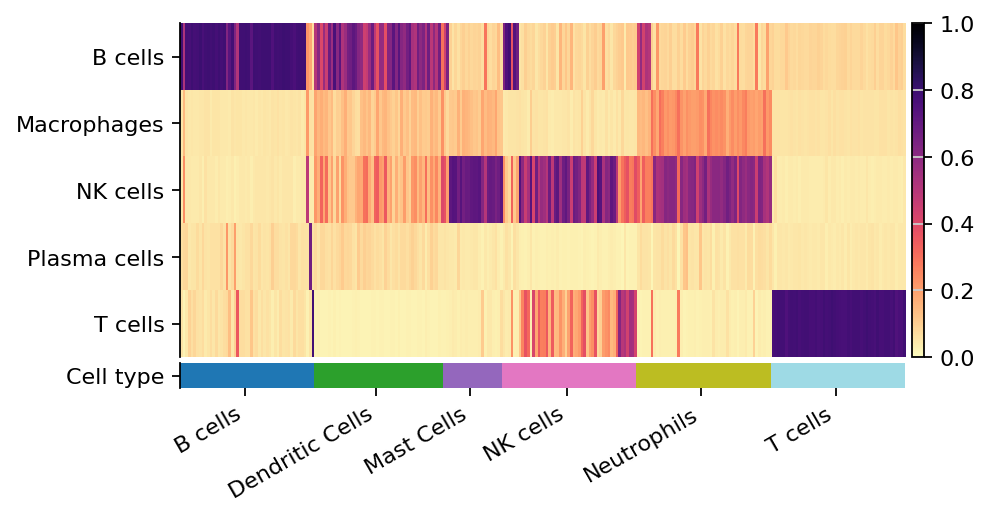

In [30]:
name_label = 'celltype'
cols_anno = ['celltype', 'predicted'][:]
df_probs = obs[list(classes)]


gs = pl.wrapper_heatmap_scores(
        df_probs.iloc[obs_ids2], obs.iloc[obs_ids2], ignore_index=True,
        col_label='celltype', col_pred='predicted',
        n_subsample=50,  # sampling 50 cells for each group
        cmap_heat='magma_r',
        fp=figdir / f'heatmap_probas.png'
    )

gs.figure

# 2 Further analysis

In [31]:
hidden_list = came.load_hidden_states(resdir / 'hidden_list.h5')
hidden_list  # a list of dicts
h_dict = hidden_list[-1] # the last layer of hidden states
h_dict

{'cell': array([[-3.8516461e-03,  4.0840134e-01, -3.1073082e-02, ...,
          9.2098820e-01, -3.4821488e-02, -0.0000000e+00],
        [-6.9798445e-03, -6.5742955e-02, -9.9809645e-03, ...,
          3.1795877e-01, -5.3852394e-02,  1.1885273e+00],
        [-9.7914692e-03,  4.1902524e-01, -5.0122462e-02, ...,
          0.0000000e+00,  6.0305947e-01, -8.2576416e-02],
        ...,
        [-3.4723572e-02,  0.0000000e+00, -4.4676922e-02, ...,
          0.0000000e+00,  9.2096037e-01, -1.7942084e-02],
        [ 4.7185478e-01,  7.1837604e-01, -8.4873021e-02, ...,
         -2.9607926e-02,  0.0000000e+00, -6.8688713e-02],
        [ 0.0000000e+00, -4.1326554e-04, -3.6040861e-02, ...,
          2.3185635e+00,  0.0000000e+00, -3.9320104e-02]], dtype=float32),
 'gene': array([[-0.02615277,  0.5110059 ,  0.2046273 , ..., -0.0420417 ,
         -0.        , -0.03792867],
        [ 2.0885503 , -0.        ,  0.849646  , ...,  0.31340745,
         -0.08439436, -0.03727404],
        [-0.        ,  0.99023

In [32]:
adt = pp.make_adata(h_dict['cell'], obs=dpair.obs, assparse=False, ignore_index=True)
gadt = pp.make_adata(h_dict['gene'], obs=dpair.var.iloc[:, :2], assparse=False, ignore_index=True)

adt.write(resdir / 'adt_hidden_cell.h5ad')
gadt.write_h5ad(resdir / 'adt_hidden_gene.h5ad')

adding columns to `adata.obs` (ignore_index=True):
adding columns to `adata.obs` (ignore_index=True):


In [33]:
print(adt)
print(gadt)

AnnData object with n_obs × n_vars = 27527 × 128
    obs: 'original_name', 'dataset', 'REF', 'celltype', 'predicted', 'max_probs', 'is_right', 'NK cells', 'B cells', 'T cells', 'Plasma cells', 'Macrophages'
AnnData object with n_obs × n_vars = 5720 × 128
    obs: 'name', 'dataset'


In [58]:
# 1. 检查数据维度匹配性
print("数据维度检查:")
print(f"h_dict['cell'] 形状: {h_dict['cell'].shape}")
print(f"dpair.obs 形状: {dpair.obs.shape}")

# 2. 手动创建 AnnData 验证 obs 合并
from anndata import AnnData
import pandas as pd

# 假设 h_dict['cell'] 是 (n_cells, n_features) 的矩阵
n_cells = h_dict['cell'].shape[0]
test_obs = dpair.obs.iloc[:n_cells].copy()  # 确保行数一致

# 手动创建 AnnData
test_adata = AnnData(
    X=h_dict['cell'],
    obs=test_obs,
    dtype=h_dict['cell'].dtype
)

# 检查 obs 内容
print("\n手动创建的 AnnData.obs 检查:")
print(f"列名: {test_adata.obs.columns.tolist()}")
print(f"前5行: \n{test_adata.obs.head()}")

# 3. 对比自动创建与手动创建的差异
adt = pp.make_adata(h_dict['cell'], obs=dpair.obs, assparse=False, ignore_index=True)
print("\n自动创建的 AnnData.obs 检查:")
print(f"列名: {adt.obs.columns.tolist()}")
if not adt.obs.empty:
    print(f"前5行: \n{adt.obs.head()}")
else:
    print("adt.obs 为空")

数据维度检查:
h_dict['cell'] 形状: (43759, 128)
dpair.obs 形状: (43759, 16)

手动创建的 AnnData.obs 检查:
列名: ['original_name', 'dataset', 'REF', 'celltype', 'predicted', 'max_probs', 'is_right', 'MoMacDC', 'Mast cells', 'T cells', 'Neutrophils', 'NK cells', 'Plasma cells', 'B cells', 'pDC', 'RBC']
前5行: 
   original_name    dataset         REF    celltype   predicted  max_probs  \
0  bcHTNA;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.806525   
1  bcHNVA;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.805697   
2  bcALZN;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.816056   
3  bcFWBP;h1tl_1  Imm_human  Mast cells  Mast cells  Mast cells   0.746979   
4  bcBJYE;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.809668   

   is_right   MoMacDC  Mast cells   T cells  Neutrophils  NK cells  \
0      True  0.806525    0.031066  0.032417     0.018676  0.024614   
1      True  0.805697    0.028325  0.027482     0.017959  0.026307   
2      True  0.816056    0.02703

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



自动创建的 AnnData.obs 检查:
列名: ['original_name', 'dataset', 'REF', 'celltype', 'predicted', 'max_probs', 'is_right', 'MoMacDC', 'Mast cells', 'T cells', 'Neutrophils', 'NK cells', 'Plasma cells', 'B cells', 'pDC', 'RBC']
前5行: 
   original_name    dataset         REF    celltype   predicted  max_probs  \
0  bcHTNA;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.806525   
1  bcHNVA;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.805697   
2  bcALZN;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.816056   
3  bcFWBP;h1tl_1  Imm_human  Mast cells  Mast cells  Mast cells   0.746979   
4  bcBJYE;h1tl_1  Imm_human     MoMacDC     MoMacDC     MoMacDC   0.809668   

   is_right   MoMacDC  Mast cells   T cells  Neutrophils  NK cells  \
0      True  0.806525    0.031066  0.032417     0.018676  0.024614   
1      True  0.805697    0.028325  0.027482     0.017959  0.026307   
2      True  0.816056    0.027039  0.024020     0.024586  0.024178   
3      True  0.054126    0.7

## 2.1 UMAP of cell embeddings

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


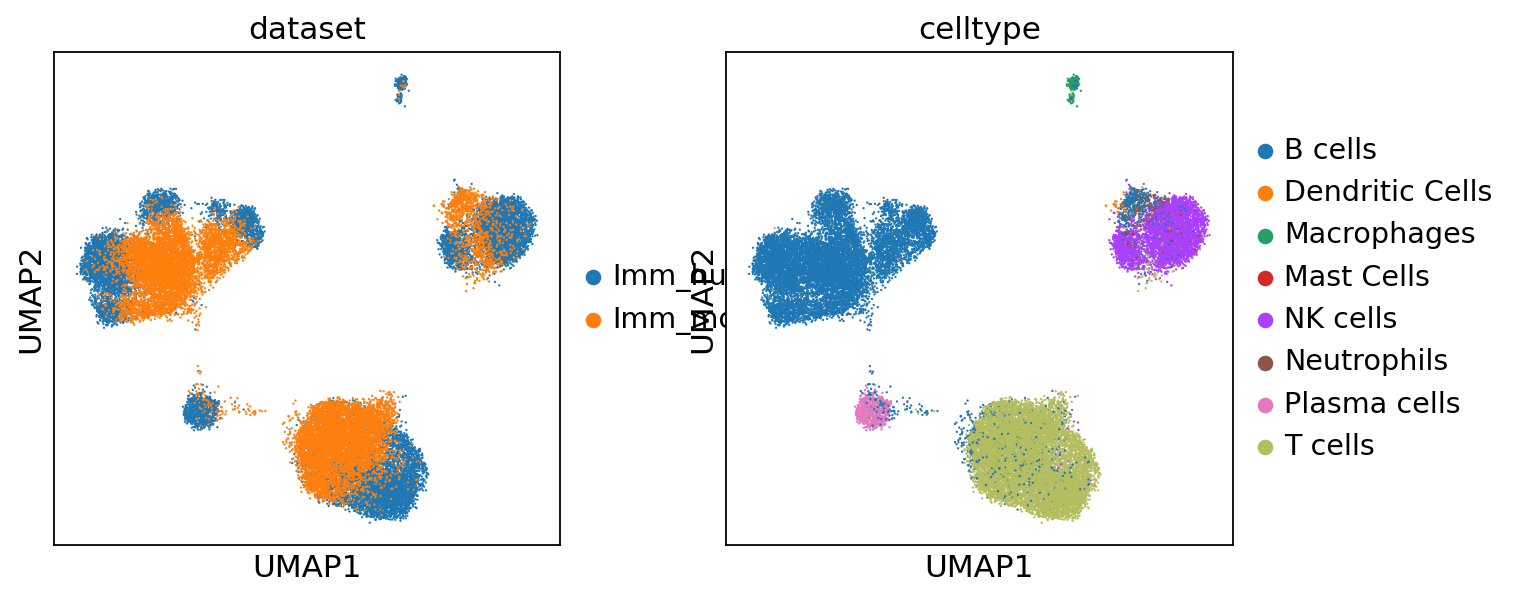

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


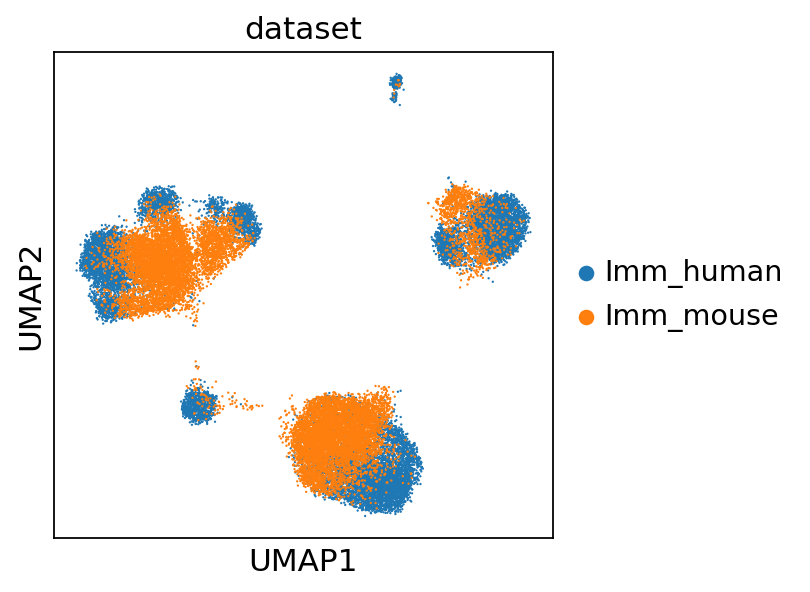

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


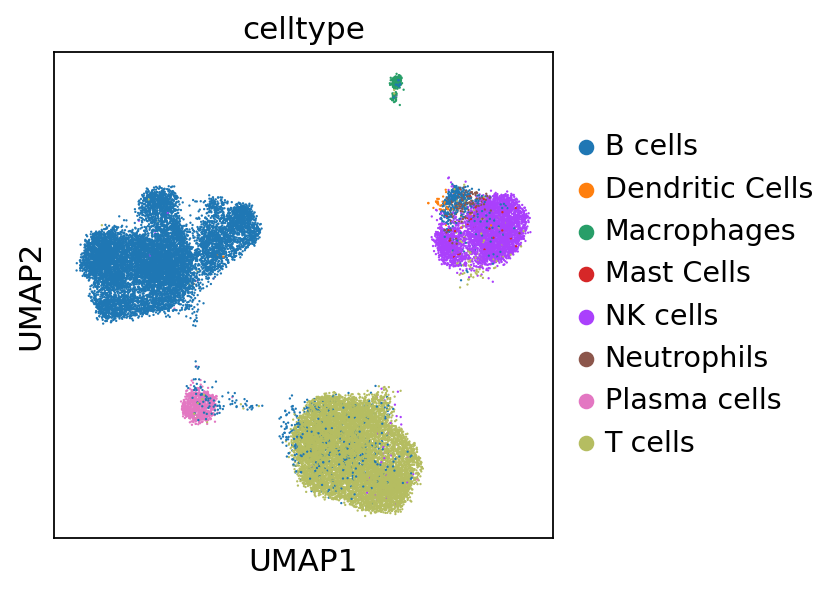

In [34]:
sc.set_figure_params(dpi_save=200)

sc.pp.neighbors(adt, n_neighbors=15, metric='cosine', use_rep='X')
sc.tl.umap(adt)
sc.pl.umap(adt, color=['dataset', 'celltype'], ncols=2)

ftype = ['.png', ''][1]
sc.pl.umap(adt, color='dataset', save=f'-dataset{ftype}')
sc.pl.umap(adt, color='celltype', save=f'-ctype{ftype}')

In [35]:
obs_umap = adt.obsm['X_umap']
obs['UMAP1'] = obs_umap[:, 0]
obs['UMAP2'] = obs_umap[:, 1]
obs.to_csv(resdir / 'obs.csv')
adt.write(resdir / 'adt_hidden_cell.h5ad')

In [36]:
adata1.obsm['X_umap'] = obs_umap[obs_ids1]
adata2.obsm['X_umap'] = obs_umap[obs_ids2]

## 2.2 UMAP of genes

In [37]:
sc.pp.neighbors(gadt, n_neighbors=15, metric='cosine', use_rep='X')

# gadt = pp.make_adata(h_dict['gene'], obs=dpair.var.iloc[:, :2], assparse=False, ignore_index=True)
sc.tl.umap(gadt)

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


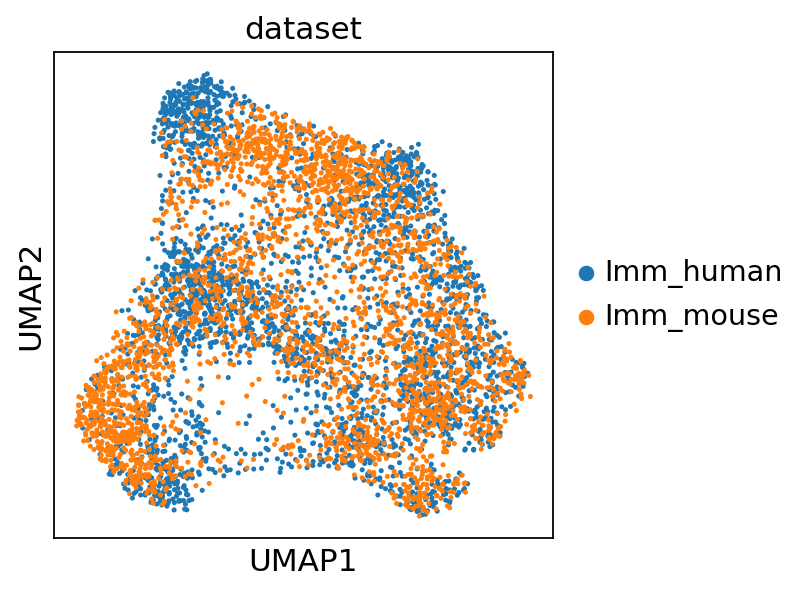

In [38]:
sc.pl.umap(gadt, color='dataset', save='_genes_n=15.png')

In [40]:
sc.pp.neighbors(gadt, n_neighbors=20, metric='cosine', use_rep='X')

# gadt = pp.make_adata(h_dict['gene'], obs=dpair.var.iloc[:, :2], assparse=False, ignore_index=True)
sc.tl.umap(gadt)

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


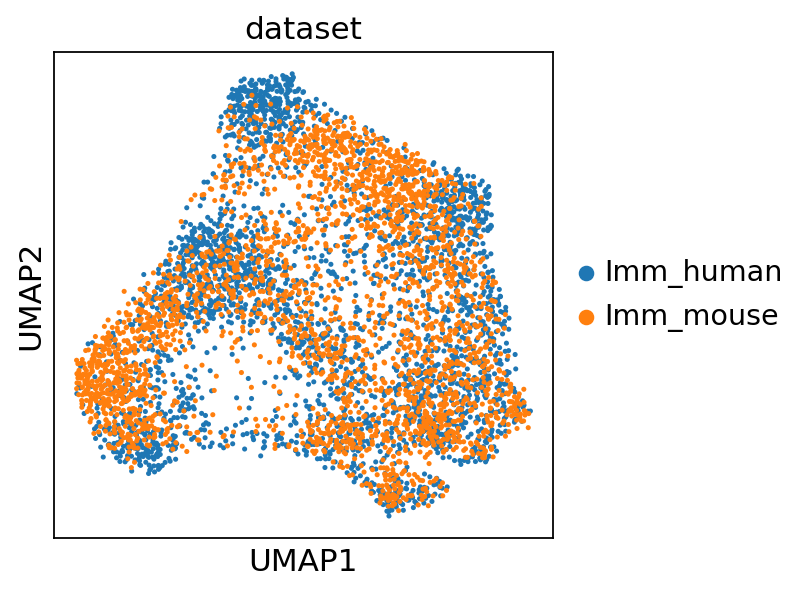

In [41]:
sc.pl.umap(gadt, color='dataset', save='_genes_n=20.png')

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


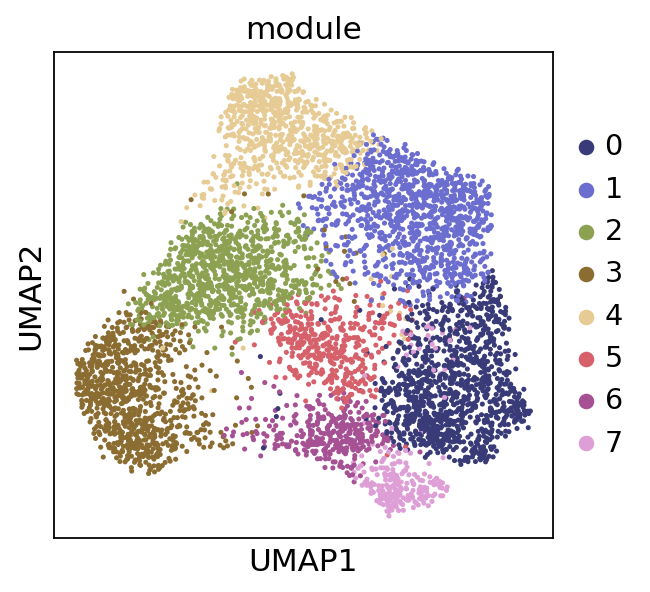

In [42]:
# joint gene module extraction
sc.tl.leiden(gadt, resolution=.8, key_added='module')
sc.pl.umap(gadt, color='module', ncols=1, palette='tab20b')

# backup results is needed
gadt.write(resdir / 'adt_hidden_gene.h5ad')

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


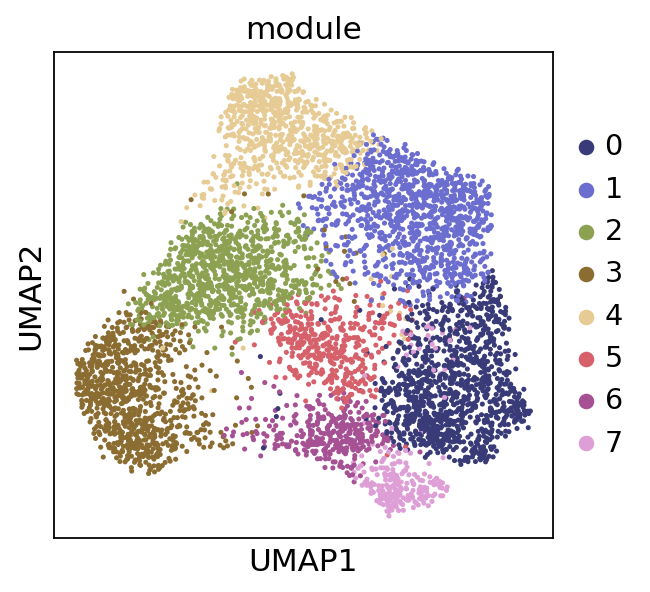

In [43]:
sc.pl.umap(gadt, color='module', ncols=1, save='_gene_module.png')

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


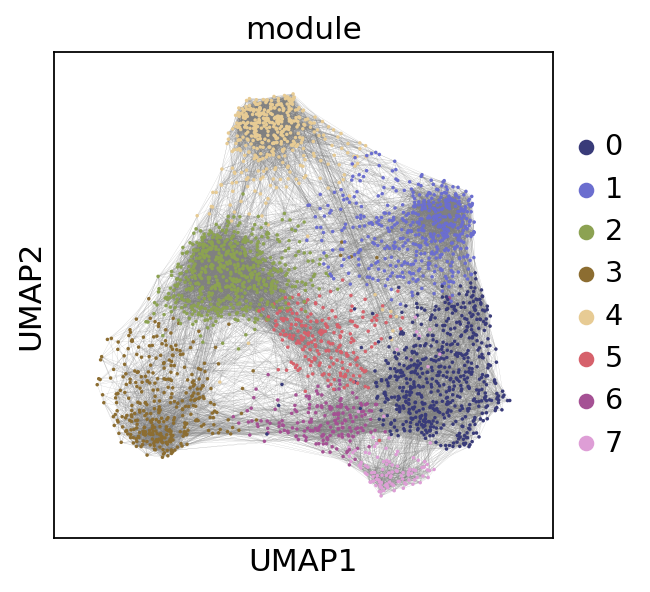

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


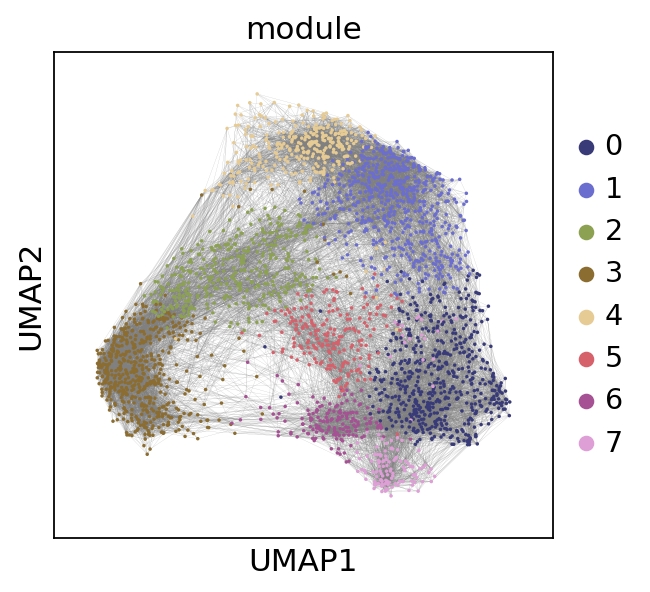

In [44]:
# gadt.obs_names = gadt.obs_names.astype(str)
# dsnames = ('Imm_human', 'Imm_mouse')  # the dataset names, set by user
gadt1, gadt2 = pp.bisplit_adata(gadt, 'dataset', dsnames[0], reset_index_by='name')

color_by = 'module'
palette = 'tab20b'
sc.pl.umap(gadt1, color=color_by, s=10, edges=True, edges_width=0.05,
           palette=palette,
           save=f'_{color_by}-{dsnames[0]}.png')
sc.pl.umap(gadt2, color=color_by, s=10, edges=True, edges_width=0.05,
           palette=palette,
           save=f'_{color_by}-{dsnames[1]}.png')

In [45]:
df_var_links = came.weight_linked_vars(
    gadt.X, dpair._vv_adj, names=dpair.get_vnode_names(),
    matric='cosine', index_names=dsnames,
)

gadt1.write(resdir / 'adt_hidden_gene1.h5ad')
gadt2.write(resdir / 'adt_hidden_gene2.h5ad')

## came.utils.analyze.compare_modules

In [46]:
mod_labels1 = gadt1.obs["module"]
mod_labels2 = gadt2.obs["module"]

In [47]:
result = came.utils.analyze.compare_modules(
    mod_labels1, 
    mod_labels2, 
    df_var_links)

In [48]:
import pandas as pd

# 初始化列表存储每个模块的信息
module_info = []

# 遍历每个模块（result的键）
for mod_id, mod_data in result.items():
    # 提取基因列表
    genes1 = mod_data.get('genes1', [])
    genes2 = mod_data.get('genes2', [])
    genes_common1 = mod_data.get('genes_common1', [])
    genes_common2 = mod_data.get('genes_common2', [])
    
    # 计算基因数量
    n_genes1 = len(genes1)
    n_genes2 = len(genes2)
    n_common1 = len(genes_common1)
    n_common2 = len(genes_common2)
    n_private1 = n_genes1 - n_common1  # 数据集1私有基因数
    n_private2 = n_genes2 - n_common2  # 数据集2私有基因数
    
    # 存储模块信息
    module_info.append({
        '模块ID': mod_id,
        '数据集1_基因数': n_genes1,
        '数据集2_基因数': n_genes2,
        '公共基因数': n_common1,
        '数据集1_私有基因数': n_private1,
        '数据集2_私有基因数': n_private2,
    })

# 转换为DataFrame
df_module_gene = pd.DataFrame(module_info)
df_module_gene

,模块ID,数据集1_基因数,数据集2_基因数,公共基因数,数据集1_私有基因数,数据集2_私有基因数
0,0,581,542,358,223,184
1,1,490,578,292,198,286
2,2,591,361,299,292,62
3,3,349,528,459,-110,69
4,4,416,307,279,137,28
5,5,209,195,136,73,59
6,6,177,161,112,65,49
7,7,107,128,14,93,114


In [49]:
import pandas as pd
from itertools import zip_longest

# 初始化列表存储所有基因信息
all_genes_info = []

# 遍历每个模块
for mod_id, mod_data in result.items():
    # 提取各个基因列表
    genes1 = mod_data.get('genes1', [])
    genes2 = mod_data.get('genes2', [])
    genes_common1 = mod_data.get('genes_common1', [])
    genes_common2 = mod_data.get('genes_common2', [])
    weights = mod_data.get('weights_common', [])
    
    # 区分基因类型
    # 参考物种中的私有基因 = genes1 中不在 genes_common1 中的基因
    private_genes1 = [g for g in genes1 if g not in genes_common1]
    
    # 查询物种中的私有基因 = genes2 中不在 genes_common2 中的基因
    private_genes2 = [g for g in genes2 if g not in genes_common2]
    
    # 合并所有基因类型，用zip_longest对齐
    max_len = max(len(genes_common1), len(genes_common2), 
                  len(private_genes1), len(private_genes2))
    
    for i in range(max_len):
        row = {
            '模块ID': mod_id,
            '公共基因_参考物种': genes_common1[i] if i < len(genes_common1) else '',
            '公共基因_查询物种': genes_common2[i] if i < len(genes_common2) else '',
            '公共基因权重值': weights[i] if i < len(weights) else '',
            '私有基因_参考物种': private_genes1[i] if i < len(private_genes1) else '',
            '私有基因_查询物种': private_genes2[i] if i < len(private_genes2) else '',
        }
        all_genes_info.append(row)

# 创建DataFrame
df_all_genes = pd.DataFrame(all_genes_info)
df_all_genes.head(20)  # 查看前20行

,模块ID,公共基因_参考物种,公共基因_查询物种,公共基因权重值,私有基因_参考物种,私有基因_查询物种
0,0,TRBV20-1,Trbv20,0.959685,TEPP,Il2ra
1,0,GADD45G,Gadd45g,0.957949,TCEA3,9230104M06Rik
2,0,TRAV12-3,Trav7-1,0.956032,SLAMF1,Tcrg-C1
3,0,AQP3,Aqp3,0.954168,TRAV21,Trav14n-3
4,0,GZMK,Gzmk,0.944768,FAM19A2,Gimap5
5,0,TRAV13-1,Trav10n,0.944598,TRBV12-4,Gucy1b1
6,0,TRAV26-2,Trav21-dv12,0.933988,TRGV3,Ms4a6b
7,0,EGR2,Egr2,0.933739,SLC7A10,Cxcr1
8,0,DGKZ,Dgkz,0.931371,ACER1,Casc1
9,0,TRAV12-3,Trav7d-3,0.928868,LGALS3BP,Znrf3


In [50]:
df_all_genes.to_csv("module_common_weights.csv", index=False, encoding="utf-8")

In [51]:
# 初始化列表存储统计信息
module_stats = []

for mod_id, mod_data in result.items():
    genes1 = mod_data.get('genes1', [])
    genes2 = mod_data.get('genes2', [])
    genes_common1 = mod_data.get('genes_common1', [])
    genes_common2 = mod_data.get('genes_common2', [])
    
    # 私有基因
    private_genes1 = [g for g in genes1 if g not in genes_common1]
    private_genes2 = [g for g in genes2 if g not in genes_common2]
    
    # 计算数量
    stats = {
        '模块ID': mod_id,
        '参考物种基因总数': len(genes1),
        '查询物种基因总数': len(genes2),
        '公共基因数': len(genes_common1),  # 假设genes_common1和genes_common2数量相同
        '参考物种私有基因数': len(private_genes1),
        '查询物种私有基因数': len(private_genes2),
        '参考物种公共基因比例': f"{len(genes_common1)/len(genes1)*100:.1f}%" if len(genes1) > 0 else "0%",
        '查询物种公共基因比例': f"{len(genes_common2)/len(genes2)*100:.1f}%" if len(genes2) > 0 else "0%",
    }
    module_stats.append(stats)

df_module_stats = pd.DataFrame(module_stats)
df_module_stats

,模块ID,参考物种基因总数,查询物种基因总数,公共基因数,参考物种私有基因数,查询物种私有基因数,参考物种公共基因比例,查询物种公共基因比例
0,0,581,542,358,291,216,61.6%,66.1%
1,1,490,578,292,234,315,59.6%,50.5%
2,2,591,361,299,296,93,50.6%,82.8%
3,3,349,528,459,147,269,131.5%,86.9%
4,4,416,307,279,172,64,67.1%,90.9%
5,5,209,195,136,74,68,65.1%,69.7%
6,6,177,161,112,66,49,63.3%,69.6%
7,7,107,128,14,94,114,13.1%,10.9%


In [52]:
df_module_stats.to_csv("module_stats.csv", index=False, encoding="utf-8")

In [60]:
result = came.utils.analyze.compare_modules(
    mod_labels1, 
    mod_labels2, 
    df_var_links,
    avg_scaled=[avg_expr1, avg_expr2])

KeyError: 'Dendritic Cells'

## 2.3 Gene-expression-profiles (for each cell type) on gene UMAP

In [54]:
# averaged expressions
avg_expr1 = pp.group_mean_adata(
    adatas[0], groupby=key_class1,
    features=dpair.vnode_names1, use_raw=True)
avg_expr2 = pp.group_mean_adata(
    adatas[1], groupby=key_class2 if key_class2 else 'predicted',
    features=dpair.vnode_names2, use_raw=True)

Computing averages grouped by cell_type
Computing averages grouped by cell_type


In [55]:
avg_expr1

,B cells,Macrophages,NK cells,Plasma cells,T cells
IGHV3-15,0.273025,0.201923,0.161113,73.457333,0.159491
KLRF1,0.115452,0.076923,1.378684,0.134667,0.279159
IGHV1-14,0.004365,0.000000,0.000000,0.005333,0.000000
TEPP,0.002401,0.000000,0.007436,0.001333,0.014554
TCEA3,0.003274,0.000000,0.003856,0.005333,0.029513
...,...,...,...,...,...
OTOF,0.000873,0.014423,0.002479,0.001333,0.003436
IGLV7-35,0.004801,0.000000,0.000275,0.000000,0.000000
AL512343.2,0.001528,0.004808,0.000551,0.004000,0.000606
TRAV6,0.008512,0.004808,0.005233,0.006667,0.064079


In [56]:
avg_expr2

,B cells,Dendritic Cells,Mast Cells,NK cells,Neutrophils,T cells
Stard8,0.004847,0.020833,0.000000,0.002141,0.039370,0.000349
Il2ra,0.013259,0.020833,0.000000,0.010707,0.039370,0.060548
Myof,0.025948,0.000000,0.000000,0.004283,0.015748,0.001396
Igkv8-21,0.133590,0.000000,0.000000,0.036403,0.000000,0.004537
Rpl12,8.610066,9.187500,4.000000,5.779443,3.417323,15.596754
...,...,...,...,...,...,...
Otof,0.000855,0.000000,0.000000,0.000000,0.000000,0.000000
Gas7,0.006701,0.333333,0.000000,0.057816,0.039370,0.004537
Igkv8-26,0.002424,0.000000,0.000000,0.000000,0.000000,0.000000
Fcer1g,0.628743,7.687500,9.681818,10.034261,5.944882,0.093003


In [57]:
plkwds = dict(cmap='RdYlBu_r', vmax=2.5, vmin=-1.5, do_zscore=True,
              axscale=3, ncols=5, with_cbar=True)

fig1, axs1 = pl.adata_embed_with_values(
    gadt1, avg_expr1,
    fp=figdir / f'umap_exprAvgs-{dsnames[0]}-all.png',
    **plkwds)
fig2, axs2 = pl.adata_embed_with_values(
    gadt2, avg_expr2,
    fp=figdir / f'umap_exprAvgs-{dsnames[1]}-all.png',
    **plkwds)

figure has been saved into:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs/umap_exprAvgs-Imm_human-all.png
figure has been saved into:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs/umap_exprAvgs-Imm_mouse-all.png


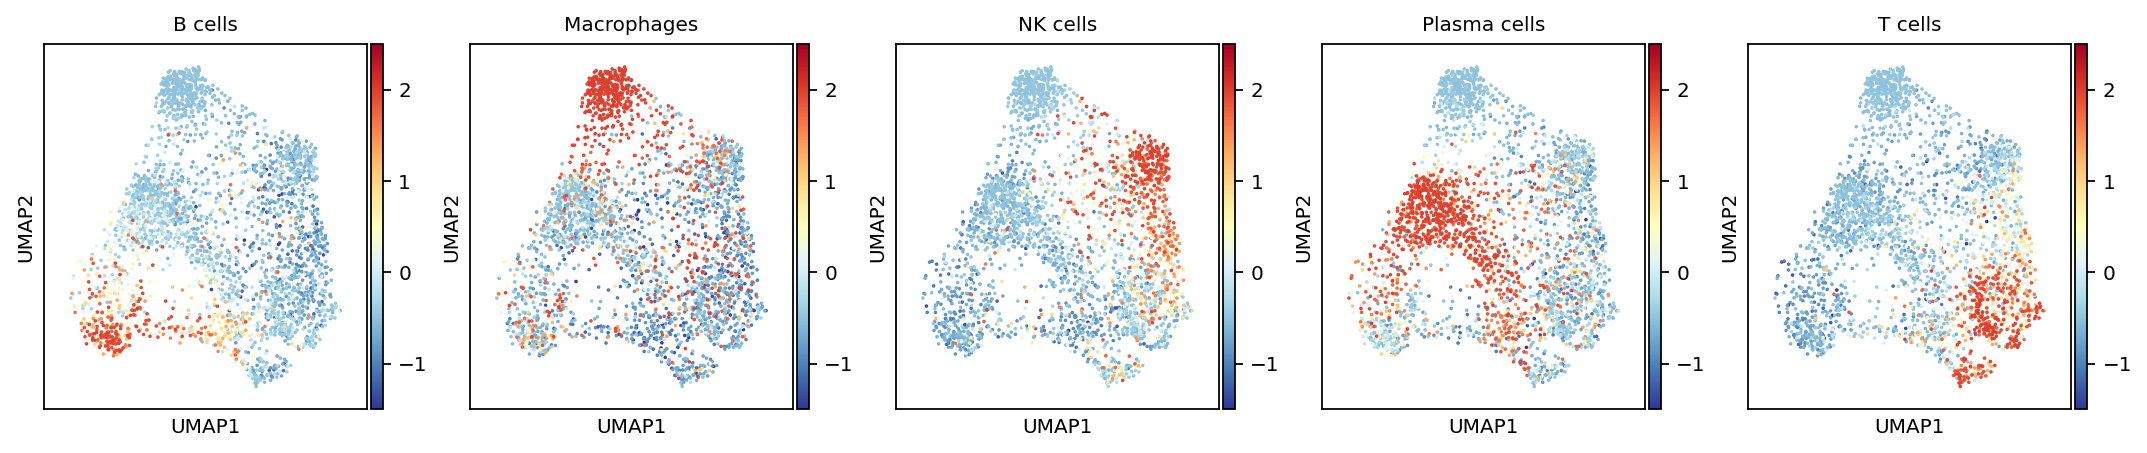

In [58]:
fig1

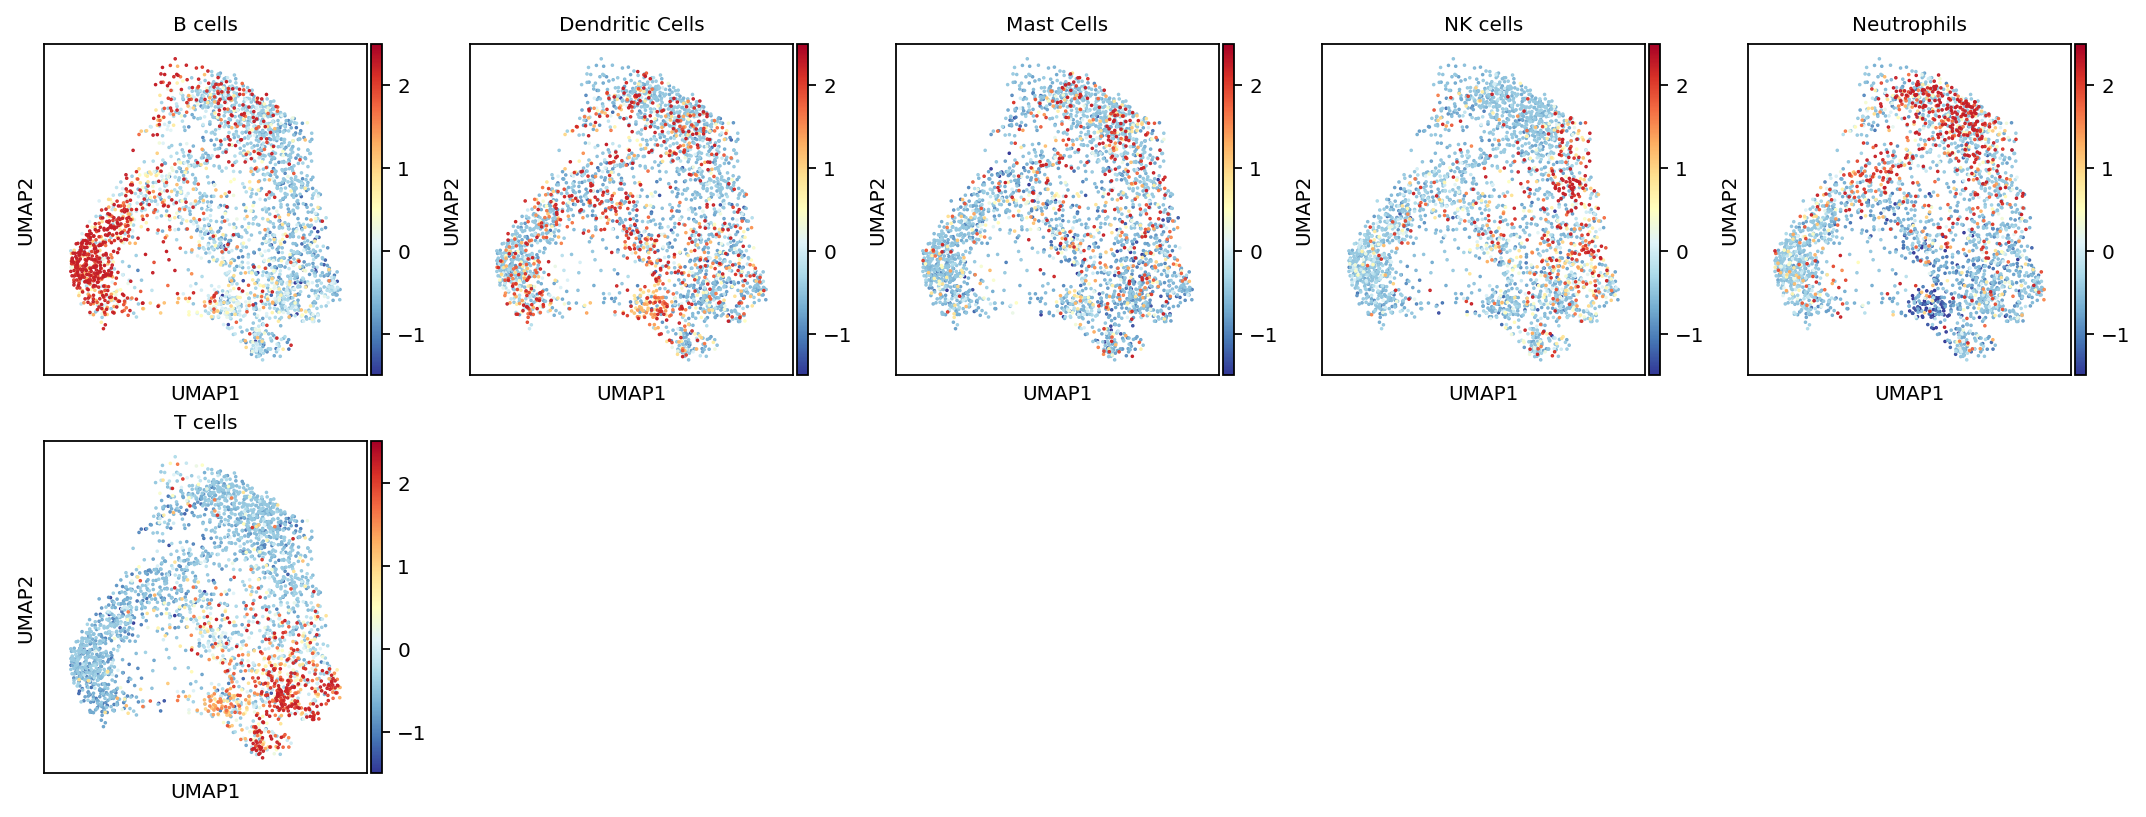

In [59]:
fig2

## 2.4 Abstracted graph

In [61]:
norm_ov = ['max', 'zs', None][1]
cut_ov = 0.

groupby_var = 'module'
obs_labels1, obs_labels2 = adt.obs['celltype'][dpair.obs_ids1], \
                           adt.obs['celltype'][dpair.obs_ids2]
var_labels1, var_labels2 = gadt1.obs[groupby_var], gadt2.obs[groupby_var]

sp1, sp2 = 'human', 'mouse'
g = came.make_abstracted_graph(
    obs_labels1, obs_labels2,
    var_labels1, var_labels2,
    avg_expr1, avg_expr2,
    df_var_links,
    tags_obs=(f'{sp1} ', f'{sp2} '),
    tags_var=(f'{sp1} module ', f'{sp2} module '),
    cut_ov=cut_ov,
    norm_mtd_ov=norm_ov,
)

figure has been saved into:
	_temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/figs/abstracted_graph-module-cut0.0-zs.png


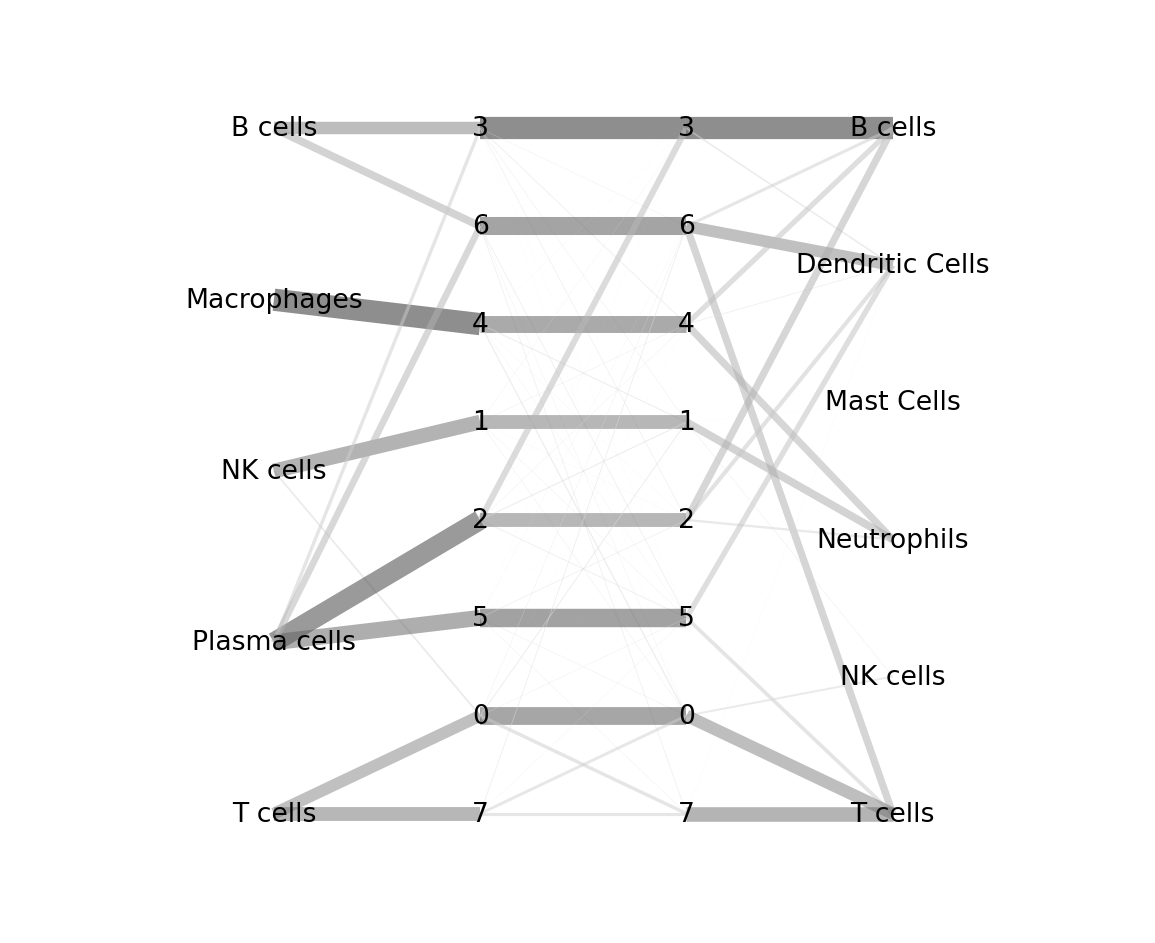

In [63]:
''' visualization '''
fp_abs = figdir / f'abstracted_graph-{groupby_var}-cut{cut_ov}-{norm_ov}.png'

ax = pl.plot_multipartite_graph(
    g, edge_scale=10,
    figsize=(9, 7.5), alpha=0.5, fp=fp_abs)  # nodelist=nodelist,

ax.figure

In [64]:
# save abstracted-graph object
came.save_pickle(g, resdir / 'abs_graph.pickle')

object saved into:
	 _temp/('Imm_human', 'Imm_mouse')-(04-21 17.06.34)/abs_graph.pickle


## 识别每个簇的特征基因

In [45]:
sc.tl.rank_genes_groups

<function scanpy.tools._rank_genes_groups.rank_genes_groups(adata: anndata._core.anndata.AnnData, groupby: str, use_raw: Union[bool, NoneType] = None, groups: Union[Literal['all'], Iterable[str]] = 'all', reference: str = 'rest', n_genes: Union[int, NoneType] = None, rankby_abs: bool = False, pts: bool = False, key_added: Union[str, NoneType] = None, copy: bool = False, method: Union[Literal['logreg', 't-test', 'wilcoxon', 't-test_overestim_var'], NoneType] = None, corr_method: Literal['benjamini-hochberg', 'bonferroni'] = 'benjamini-hochberg', tie_correct: bool = False, layer: Union[str, NoneType] = None, **kwds) -> Union[anndata._core.anndata.AnnData, NoneType]>

/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/public/workspace/lhpeng/miniconda3/envs/env_came/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py

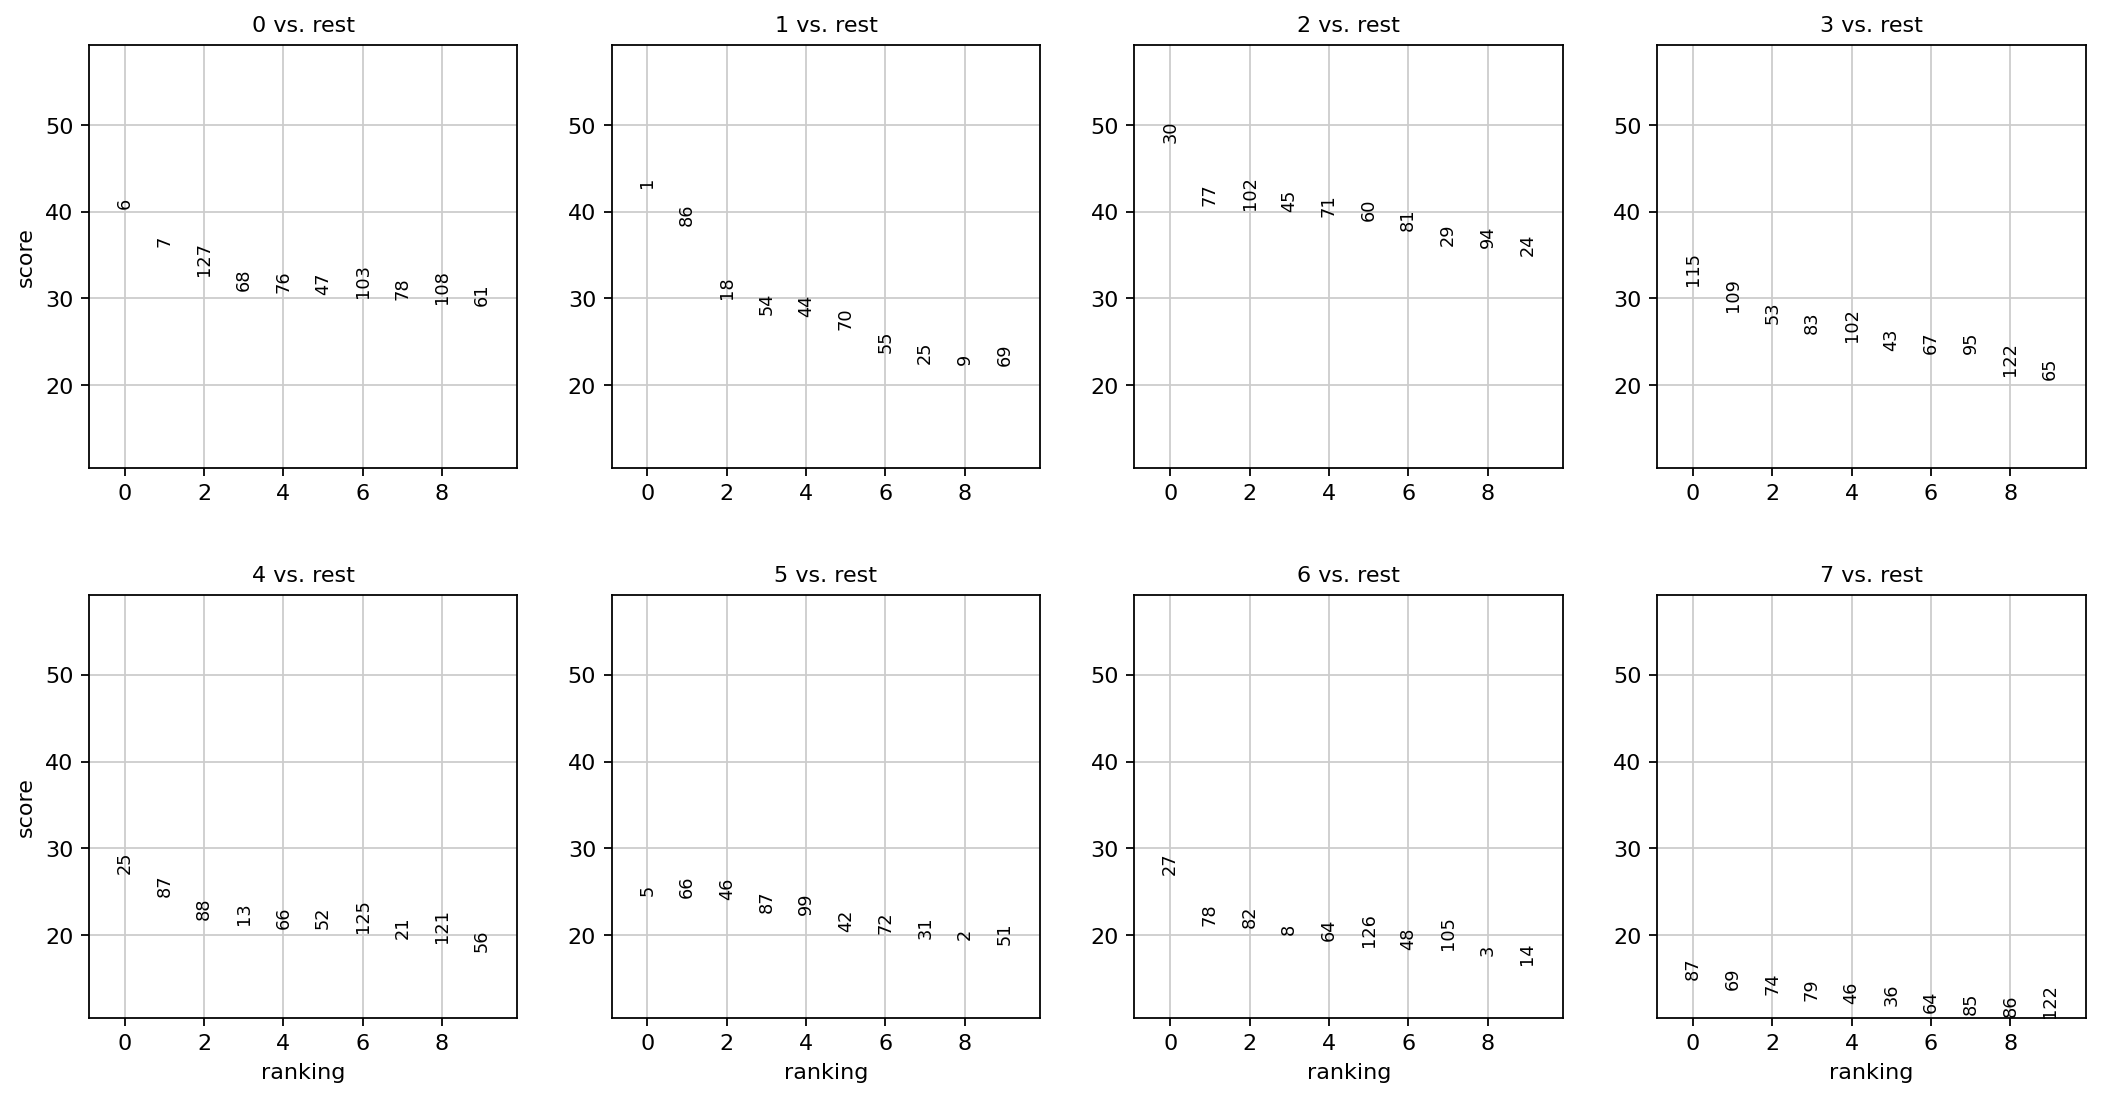

In [36]:
# 计算每个 module 的特征基因（默认用 t 检验，可根据数据调整方法）
sc.tl.rank_genes_groups(
    gadt, 
    groupby='module',  # 按整合后的细胞簇分组
    method='wilcoxon',  # 推荐用于单细胞的非参数检验（抗噪声）
    n_genes=200,  # 每个簇保留 top200 特征基因
    key_added='rank_genes_module'  # 结果存储的键名（避免覆盖默认值）
)

# 查看结果（以 module 0 为例）
sc.pl.rank_genes_groups(gadt, group='0', key='rank_genes_module', n_genes=10)  # 可视化 top10 基因

In [52]:
# 提取所有簇的差异基因（包含基因名）
diff_genes_df = sc.get.rank_genes_groups_df(
    gadt, 
    group='0',
    key='rank_genes_module'  # 需与 sc.tl.rank_genes_groups 中的 key_added 一致
)

# 查看前几行（包含基因名、差异分数、log2倍数变化等信息）
print(diff_genes_df.head())

  names     scores  logfoldchanges          pvals      pvals_adj
0    98  38.070648        3.288095   0.000000e+00   0.000000e+00
1     0  37.930065        3.219521   0.000000e+00   0.000000e+00
2     7  37.674236             NaN  1.312429e-310  4.199774e-309
3    67  37.130768        3.065401  8.959593e-302  2.293656e-300
4    84  33.123665        2.460464  1.356431e-240  2.170290e-239


In [62]:
gadt

AnnData object with n_obs × n_vars = 7431 × 128
    obs: 'name', 'dataset', 'module'
    uns: 'neighbors', 'umap', 'dataset_colors', 'leiden', 'module_colors', 'rank_genes_module'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [84]:
gadt.obs

,name,dataset,module
0,TIMP1,Imm_human,3
1,PDLIM1,Imm_human,1
2,MED26,Imm_human,4
3,IL9R,Imm_human,1
4,BPNT1,Imm_human,2
...,...,...,...
7426,Foxs1,Imm_mouse,6
7427,Sesn3,Imm_mouse,1
7428,Ebag9,Imm_mouse,1
7429,Fam189b,Imm_mouse,2


In [83]:
gadt.obs['name']

0         TIMP1
1        PDLIM1
2         MED26
3          IL9R
4         BPNT1
         ...   
7426      Foxs1
7427      Sesn3
7428      Ebag9
7429    Fam189b
7430       Rae1
Name: name, Length: 7431, dtype: category
Categories (7426, object): ['0610010K14Rik', '1110004E09Rik', '1110059E24Rik', '1110059G10Rik', ..., 'mt-Nd2', 'mt-Nd3', 'mt-Nd4', 'mt-Nd5']

In [72]:
# 假设真实基因名存在 gadt.var['gene_name'] 列
gene_name_mapping = gadt.obs['name']  # 索引是数字，值是真实基因名

# 重新映射
diff_genes_df['real_gene_name'] = diff_genes_df['names'].map(gene_name_mapping)
print(diff_genes_df[['names', 'real_gene_name', 'scores', 'pvals_adj']].head())

  names real_gene_name     scores      pvals_adj
0    98           SOD2  38.070648   0.000000e+00
1     0          TIMP1  37.930065   0.000000e+00
2     7          CCSAP  37.674236  4.199774e-309
3    67          MMP11  37.130768  2.293656e-300
4    84          PSMD5  33.123665  2.170290e-239


In [63]:
print("所有 module 编号：", gadt.obs['module'].unique())

所有 module 编号： ['3', '1', '4', '2', '8', ..., '5', '0', '9', '7', '10']
Length: 11
Categories (11, object): ['0', '1', '2', '3', ..., '7', '8', '9', '10']


In [65]:
# 提取每个簇的 top 特征基因（例如 top50）
top_genes_per_module = {}
for module in gadt.obs['module'].unique():
    # 从 .uns 中提取该簇的基因排序
    genes = gadt.uns['rank_genes_module']['names'][module]
    top_genes_per_module[module] = list(genes[:50])  # 取前50个

# 示例：查看 module 1 的 top10 特征基因
print("Module 1 特征基因：", top_genes_per_module['0'][:10])

Module 1 特征基因： ['98', '0', '7', '67', '84', '56', '32', '19', '94', '70']


In [42]:
print(f"数据维度（基因×样本）：{gadt.shape}")
print("基因簇列名：", 'module' in gadt.obs.columns)  # 确认存在基因簇标注
print("基因名示例：", gadt.obs['name'].head().tolist())

数据维度（基因×样本）：(7431, 128)
基因簇列名： True
基因名示例： ['DPH2', 'AC243829.1', 'LINC01527', 'GIMAP7', 'UGDH']


In [41]:
print(gadt_samples.obs.columns)  # 查看所有可用的观测列

Index([], dtype='object')


In [37]:
# 1. 转置数据为样本×基因维度（适应scanpy的默认分析格式）
# 转置后：行=样本，列=基因（基因名存于var.index），obs存储样本信息
gadt_samples = gadt.T
# 原基因的簇信息需转为var的列（标注每个基因属于哪个簇）
gadt_samples.var['module'] = gadt.obs['module'].values  # 关联基因簇信息到var

In [44]:
gadt

AnnData object with n_obs × n_vars = 7431 × 128
    obs: 'name', 'dataset', 'module'
    uns: 'neighbors', 'umap', 'dataset_colors', 'leiden', 'module_colors', 'rank_genes_module', 'rank_genes_gene_module'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [43]:
gadt_samples

AnnData object with n_obs × n_vars = 128 × 7431
    var: 'name', 'dataset', 'module'
    uns: 'neighbors', 'umap', 'dataset_colors', 'leiden', 'module_colors', 'rank_genes_module', 'rank_genes_gene_module'
    varm: 'X_umap'
    varp: 'distances', 'connectivities'

In [46]:
def assign_sample_group(adata, original_gene_obs):
    """为样本分配分组（基于高表达基因的所属簇）"""
    # 原始基因的簇信息（来自原obs['module']）
    gene_module = original_gene_obs['module']
    # 对每个样本，找到表达量最高的基因
    top_gene_idx = adata.X.argmax(axis=1)  # 每个样本中表达量最高的基因索引
    # 映射到该基因所属的簇，作为样本的分组
    sample_groups = [gene_module.iloc[idx] for idx in top_gene_idx]
    # 存储到样本的obs中
    adata.obs['sample_group'] = sample_groups
    return adata

# 执行样本分组（使用原始gadt的obs信息，即基因簇标注）
gadt_samples = assign_sample_group(gadt_samples, gadt.obs)

In [56]:
gadt_samples.var

,name,dataset,module
0,DPH2,Imm_human,0
1,AC243829.1,Imm_human,1
2,LINC01527,Imm_human,1
3,GIMAP7,Imm_human,5
4,UGDH,Imm_human,1
...,...,...,...
7426,A330017A19Rik,Imm_mouse,1
7427,Rpl19-ps11,Imm_mouse,0
7428,Tmem47,Imm_mouse,0
7429,Rpl30,Imm_mouse,0


In [47]:
# 3. 现在groupby使用obs中的列（样本分组），比较不同样本组的基因表达差异
# 本质：通过样本分组间接反映基因簇的表达特异性
sc.tl.rank_genes_groups(
    gadt_samples,
    groupby='sample_group',  # 正确使用obs中的列
    method='wilcoxon',
    n_genes=200,
    key_added='rank_genes_gene_module'
)

In [50]:
# 4. 提取特征基因（基因名来自var.index，即原始obs['name']）
def get_markers(adata, key, group, top_n=50):
    marker_df = sc.get.rank_genes_groups_df(adata, group=group, key=key)
    # 关键：从var['name']映射基因名（'names'列是var的索引）
    marker_df['gene_name'] = marker_df['names'].map(
        dict(zip(adata.var.index, adata.var['name']))  # var.index → var['name']
    )
    return marker_df.sort_values('scores', ascending=False).head(top_n)

In [51]:
# 5. 批量提取所有基因簇的特征基因
sample_groups = gadt_samples.obs['sample_group'].unique()
gene_cluster_markers = {}

for group in sample_groups:
    markers = get_markers(gadt_samples, 'rank_genes_gene_module', group)
    gene_cluster_markers[group] = markers
    print(f"基因簇 {group} 的top10特征基因：")
    print(markers[['gene_name', 'scores']].head(10), "\n")

基因簇 6 的top10特征基因：
  gene_name    scores
0     H2-Ob  3.944332
1    Fcer2a  3.735875
2      FCMR  3.654127
3    H2-Eb1  3.629603
4      TCF4  3.613253
5   HLA-DOB  3.576467
6   BCL2L10  3.572380
7      CD22  3.547855
8   Slc15a4  3.523331
9    SETBP1  3.466107 

基因簇 1 的top10特征基因：
    gene_name    scores
0         CA2  4.426698
1     SNORA49  4.420688
2      KIF20A  4.390635
3        EMP3  4.381619
4      PECAM1  4.327526
5      ATP2A2  4.294468
6       DECR1  4.282447
7        DAB2  4.258405
8  AL669970.2  4.258405
9      LGALS1  4.252395 

基因簇 5 的top10特征基因：
  gene_name    scores
0    Klrb1f  6.065147
1      Xcl1  6.037675
2      Cst7  5.759906
3     IL2RB  5.592023
4      CST7  5.579813
5       Fyn  5.527922
6      Gzma  5.433298
7      XCL1  5.335620
8     Eomes  5.335620
9     KLRK1  5.292886 

基因簇 3 的top10特征基因：
  gene_name    scores
0     Nsmaf  4.170557
1    Trim33  4.086680
2      BTG1  4.058721
3     FOXJ3  4.021442
4      PYGM  3.918926
5      SLU7  3.900286
6     SENP2  3.90028

In [57]:
# 确认基因簇信息位置：var中的'module'列
print("基因簇信息示例：", gadt_samples.var['module'].head().tolist())
print("基因名示例（var['name']）：", gadt_samples.var['name'].head().tolist())

# 1. 将var中的基因簇信息转换为样本分组（存储到obs中）
# 逻辑：每个样本的分组由其高表达基因所属的基因簇决定
def var_module_to_sample_group(adata):
    # 基因索引→基因簇的映射（从var['module']获取）
    gene_to_module = dict(zip(adata.var.index, adata.var['module']))
    # 对每个样本，找到表达量最高的基因索引
    top_gene_indices = adata.X.argmax(axis=1)
    # 将基因索引转换为对应的基因簇，作为样本分组
    sample_groups = [gene_to_module[adata.var.index[idx]] for idx in top_gene_indices]
    # 存储到样本的obs中（行维度分组）
    adata.obs['module_group'] = sample_groups
    return adata

# 执行转换：为样本创建基于var['module']的分组
gadt_samples = var_module_to_sample_group(gadt_samples)

# 2. 计算特征基因（groupby使用obs中的样本分组列）
sc.tl.rank_genes_groups(
    gadt_samples,
    groupby='module_group',  # 正确使用obs中的行维度分组
    method='wilcoxon',
    n_genes=200,
    key_added='var_module_markers'
)

# 3. 提取特征基因并关联基因名（从var['name']获取）
def get_module_markers(adata, key, group, top_n=50):
    markers_df = sc.get.rank_genes_groups_df(adata, group=group, key=key)
    # 关联基因名：var.index→var['name']
    markers_df['gene_name'] = markers_df['names'].map(
        dict(zip(adata.var.index, adata.var['name']))
    )
    return markers_df.sort_values('scores', ascending=False).head(top_n)

# 4. 批量提取所有基因簇的特征基因
all_modules = gadt_samples.obs['module_group'].unique()
module_markers = {}

for module in all_modules:
    markers = get_module_markers(gadt_samples, 'var_module_markers', module)
    module_markers[module] = markers
    print(f"基因簇 {module} 的Top10特征基因：")
    print(markers[['gene_name', 'scores', 'pvals_adj']].head(10), "\n")

基因簇信息示例： ['0', '1', '1', '5', '1']
基因名示例（var['name']）： ['DPH2', 'AC243829.1', 'LINC01527', 'GIMAP7', 'UGDH']
基因簇 6 的Top10特征基因：
  gene_name    scores  pvals_adj
0     H2-Ob  3.944332   0.198313
1    Fcer2a  3.735875   0.198313
2      FCMR  3.654127   0.198313
3    H2-Eb1  3.629603   0.198313
4      TCF4  3.613253   0.198313
5   HLA-DOB  3.576467   0.198313
6   BCL2L10  3.572380   0.198313
7      CD22  3.547855   0.198313
8   Slc15a4  3.523331   0.198313
9    SETBP1  3.466107   0.198313 

基因簇 1 的Top10特征基因：
    gene_name    scores  pvals_adj
0         CA2  4.426698   0.011459
1     SNORA49  4.420688   0.011459
2      KIF20A  4.390635   0.011459
3        EMP3  4.381619   0.011459
4      PECAM1  4.327526   0.011459
5      ATP2A2  4.294468   0.011459
6       DECR1  4.282447   0.011459
7        DAB2  4.258405   0.011459
8  AL669970.2  4.258405   0.011459
9      LGALS1  4.252395   0.011459 

基因簇 5 的Top10特征基因：
  gene_name    scores  pvals_adj
0    Klrb1f  6.065147   0.000006
1      Xcl1  6.0376

In [64]:
gadt_samples.obs

,sample_group,module_group
0,6,6
1,1,1
2,5,5
3,3,3
4,5,5
...,...,...
123,7,7
124,6,6
125,4,4
126,6,6


In [65]:
gadt_samples.var

,name,dataset,module
0,DPH2,Imm_human,0
1,AC243829.1,Imm_human,1
2,LINC01527,Imm_human,1
3,GIMAP7,Imm_human,5
4,UGDH,Imm_human,1
...,...,...,...
7426,A330017A19Rik,Imm_mouse,1
7427,Rpl19-ps11,Imm_mouse,0
7428,Tmem47,Imm_mouse,0
7429,Rpl30,Imm_mouse,0


In [58]:
# 5. 保存结果
pd.concat(
    [df.assign(cluster=module) for module, df in module_markers.items()],
    ignore_index=True
).to_csv('var_module_marker_genes.csv', index=False)